# ESMM + MMoE：500 万～1000 万行深度学习实验

**默认真实生成 500 万条合成样本**，不是把少量样本重复拼接。可以将 ROWS 改为 10_000_000。
按 60%/20%/20% 划分，默认两条路径各 3 epochs：原生 PyTorch 与 torchkeras。
数据量用于展示分块数据工程、训练吞吐量与监控，并不意味着模型质量会因数据量自动提升。

先运行 `uv sync --extra torchkeras --extra tensorboard --group dev`，选择项目 `.venv` 内核。
从头执行全部单元格。完整 API 和 Hydra 说明见 [完整指南](esmm_mmoe_complete_guide.ipynb)。

## 1. 设置

大数组保存在 experiments 下，不提交 Git。500 万行约 143 MiB，1000 万行约 286 MiB，
另有模型、事件日志与临时内存。使用 mmap 不代表进程只占这些内存；精确 AUC 还需要 O(N) 的分数与标签。
复用已有数据时校验 SHA256；参数不同必须使用新数据目录。

In [1]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/phl_risk").is_dir())
sys.path.insert(0, str(REPO / "src"))
ROWS = 5_000_000  # 改成 10_000_000，即生成 1000 万行
EPOCHS = 3
BATCH_SIZE = 4096
CHUNK_SIZE = 100_000
THREADS = 4
ROOT = REPO / "experiments/esmm_mmoe_large"

In [2]:
import hashlib
import json
import math
import random
import zipfile
from copy import deepcopy
from importlib.metadata import version
from pathlib import Path
from tempfile import TemporaryDirectory
from time import perf_counter

import numpy as np
import pandas as pd
import torch
from numpy.lib.format import open_memmap
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

from phl_risk.modeling.experiment import Experiment
from phl_risk.modeling.experiment.adapters.pytorch import load_pytorch, record_pytorch
from phl_risk.modeling.experiment.configuration import read_yaml_config
from phl_risk.modeling.models.esmm_mmoe import ESMMLoss, ESMMMoE
from phl_risk.modeling.training.esmm import evaluate_esmm

## 2. 分块生成、训练区间拟合

三个 .npy 文件分别保存连续特征 float32、分类 ID int16 和标签 uint8。
概率链路与小型指南一致；每块独立采样新数据。连续缺失值由训练均值填补，
StandardScaler.partial_fit 只看前 60% 的训练区间。分类词表是生成器预先声明的语义映射，未知值为 0。
与小型指南的中位数填补不同，这里采用可流式拟合的均值填补。

In [3]:
def _sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def generate_dataset(directory, rows=5_000_000, chunk_size=100_000, seed=2026):
    """Create/reuse immutable raw memmaps; fit statistics on the train range only."""
    directory = Path(directory)
    if rows < 100 or chunk_size < 1:
        raise ValueError("rows must be >= 100 and chunk_size must be positive")
    manifest_path = directory / "manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        if (manifest["rows"], manifest["seed"], manifest["chunk_size"]) != (rows, seed, chunk_size):
            raise ValueError(
                "Requested generation differs from the existing dataset; use a new path"
            )
        for name, digest in manifest["sha256"].items():
            if _sha256(directory / name) != digest:
                raise ValueError(f"Existing dataset checksum mismatch: {name}")
        return manifest
    directory.mkdir(parents=True, exist_ok=True)
    if any(directory.iterdir()):
        raise ValueError("Use an empty directory; existing incomplete files are not overwritten")
    started = perf_counter()
    train_end, valid_end = int(rows * 0.6), int(rows * 0.8)
    boundaries = {
        "train": (0, train_end),
        "valid": (train_end, valid_end),
        "test": (valid_end, rows),
    }
    continuous = open_memmap(
        directory / "continuous.npy", mode="w+", dtype="float32", shape=(rows, 6)
    )
    categorical = open_memmap(
        directory / "categorical.npy", mode="w+", dtype="int16", shape=(rows, 2)
    )
    labels = open_memmap(directory / "labels.npy", mode="w+", dtype="uint8", shape=(rows, 2))
    scaler = StandardScaler()
    counts = {name: {"ctr": 0, "ctcvr": 0} for name in boundaries}
    rng = np.random.default_rng(seed)
    for start in range(0, rows, chunk_size):
        end = min(start + chunk_size, rows)
        n = end - start
        x = rng.standard_normal((n, 6), dtype=np.float32)
        cat = np.column_stack([rng.integers(1, 4, n), rng.integers(1, 3, n)]).astype("int16")
        p_ctr = 1 / (1 + np.exp(-(0.8 * x[:, 0] - 0.6 * x[:, 1] + 0.5 * (cat[:, 0] == 1))))
        p_cvr = 1 / (1 + np.exp(-(-0.7 + 0.9 * x[:, 2] + 0.6 * x[:, 0] - 0.3 * (cat[:, 1] == 1))))
        y_ctr = (rng.random(n) < p_ctr).astype("uint8")
        y_ctcvr = y_ctr * (rng.random(n) < p_cvr).astype("uint8")
        x[rng.random(n) < 0.03, 0] = np.nan
        cat[rng.random(n) < 0.02, 0] = 0
        continuous[start:end], categorical[start:end] = x, cat
        labels[start:end] = np.column_stack([y_ctr, y_ctcvr])
        if start < train_end:
            scaler.partial_fit(x[: min(end, train_end) - start])
        for name, (left, right) in boundaries.items():
            lo, hi = max(start, left), min(end, right)
            if lo < hi:
                counts[name]["ctr"] += int(y_ctr[lo - start : hi - start].sum())
                counts[name]["ctcvr"] += int(y_ctcvr[lo - start : hi - start].sum())
        if end == rows or end % 1_000_000 == 0:
            print(f"Generated {end:,}/{rows:,} rows", flush=True)
    for array in (continuous, categorical, labels):
        array.flush()
    del continuous, categorical, labels
    manifest = {
        "format_version": 1,
        "rows": rows,
        "seed": seed,
        "chunk_size": chunk_size,
        "partitions": {k: right - left for k, (left, right) in boundaries.items()},
        "boundaries": boundaries,
        "positive_counts": counts,
        "preprocessing": {
            "continuous_features": [f"x{i}" for i in range(6)],
            "mean": scaler.mean_.tolist(),
            "scale": scaler.scale_.tolist(),
            "imputation": "train_mean",
            "fit_partition": "train",
            "categorical_features": ["channel", "device"],
            "vocabularies": {
                "channel": {"search": 1, "feed": 2, "direct": 3},
                "device": {"mobile": 1, "desktop": 2},
            },
            "categorical_cardinalities": [4, 3],
            "unknown_category_id": 0,
        },
        "sha256": {
            name: _sha256(directory / name)
            for name in ("continuous.npy", "categorical.npy", "labels.npy")
        },
        "generation_seconds": perf_counter() - started,
        "disk_bytes": sum(p.stat().st_size for p in directory.glob("*.npy")),
    }
    manifest_path.write_text(json.dumps(manifest, indent=2))
    return manifest

In [4]:
manifest = generate_dataset(ROOT / f"dataset_{ROWS}", rows=ROWS, chunk_size=CHUNK_SIZE)
summary = pd.DataFrame(
    {
        name: {
            "rows": n,
            "ctr_rate": manifest["positive_counts"][name]["ctr"] / n,
            "ctcvr_rate": manifest["positive_counts"][name]["ctcvr"] / n,
        }
        for name, n in manifest["partitions"].items()
    }
).T
display(summary)
print("磁盘 MiB:", manifest["disk_bytes"] / 1024**2)
print("生成耗时（首次）:", manifest["generation_seconds"])
assert summary.rows.sum() == ROWS

,rows,ctr_rate,ctcvr_rate
train,3000000.0,0.533824,0.196537
valid,1000000.0,0.533425,0.196358
test,1000000.0,0.534052,0.197040


磁盘 MiB: 143.051513671875
生成耗时（首次）: 0.5480128749914002


## 3. 已分批的磁盘 DataLoader

每次只复制、标准化一个 batch。IterableDataset 直接产出完整 batch，DataLoader 设置 batch_size=None，
避免逐样本 Python 调用。训练按块随机重排，每轮变化；这不是全量逐行随机打散。
本示例固定 num_workers=0，避免多个 worker 重复读取同一区间。

In [5]:
def transform_batch(categorical, continuous, preprocessing):
    """Apply persisted train statistics, including missing-value handling."""
    x = np.array(continuous, dtype=np.float32, copy=True)
    mean = np.asarray(preprocessing["mean"], dtype=np.float32)
    scale = np.asarray(preprocessing["scale"], dtype=np.float32)
    x = np.where(np.isnan(x), mean, x)
    x = (x - mean) / scale
    cat = np.array(categorical, dtype=np.int64, copy=True)
    return torch.from_numpy(cat), torch.from_numpy(x)


class DiskBatches(IterableDataset):
    """Yield full batches from mmap; shuffle block order with O(number-of-batches) memory.

    Single-process loader by design. Already-batched iteration avoids millions
    of Python __getitem__ calls. A new deterministic block permutation is used
    for each training epoch; row-level random shuffling is not claimed.
    """

    def __init__(self, directory, partition, batch_size=4096, shuffle=False, seed=2026):
        if batch_size < 1:
            raise ValueError("batch_size must be positive")
        self.directory = Path(directory)
        self.manifest = json.loads((self.directory / "manifest.json").read_text())
        self.start, self.end = self.manifest["boundaries"][partition]
        self.batch_size, self.shuffle, self.seed, self.epoch = batch_size, shuffle, seed, 0

    def __len__(self):
        return math.ceil((self.end - self.start) / self.batch_size)

    def __iter__(self):
        if get_worker_info() is not None:
            raise ValueError("DiskBatches guide uses num_workers=0 to prevent duplicated batches")
        continuous = np.load(self.directory / "continuous.npy", mmap_mode="r")
        categorical = np.load(self.directory / "categorical.npy", mmap_mode="r")
        labels = np.load(self.directory / "labels.npy", mmap_mode="r")
        blocks = np.arange(len(self))
        if self.shuffle:
            np.random.default_rng(self.seed + self.epoch).shuffle(blocks)
            self.epoch += 1
        for block in blocks:
            left = self.start + int(block) * self.batch_size
            right = min(left + self.batch_size, self.end)
            cat, cont = transform_batch(
                categorical[left:right], continuous[left:right], self.manifest["preprocessing"]
            )
            target = np.array(labels[left:right], dtype=np.float32, copy=True)
            yield cat, cont, torch.from_numpy(target[:, 0]), torch.from_numpy(target[:, 1])


def make_disk_loaders(directory, batch_size=4096, seed=2026):
    loaders = {
        name: DataLoader(
            DiskBatches(directory, name, batch_size, seed=seed), batch_size=None, num_workers=0
        )
        for name in ("train", "valid", "test")
    }
    loaders["fit"] = DataLoader(
        DiskBatches(directory, "train", batch_size, shuffle=True, seed=seed),
        batch_size=None,
        num_workers=0,
    )
    return loaders

In [6]:
loaders = make_disk_loaders(ROOT / f"dataset_{ROWS}", batch_size=BATCH_SIZE)
probe = next(iter(loaders["fit"]))
print("每轮训练批数:", len(loaders["fit"]))
print("batch shapes:", [tuple(t.shape) for t in probe])
assert torch.all(probe[3] <= probe[2])
del probe

每轮训练批数: 733
batch shapes: [(4096, 2), (4096, 6), (4096,), (4096,)]


## 4. 原生 PyTorch 的大数据训练循环

保留 forward/backward/optimizer 的控制权。按样本汇总 loss，用 valid 选模。
每个 epoch 记录耗时，test 在训练结束后才参与最终评估。

In [7]:
def fit_native(net, loss_fn, optimizer, scheduler, loaders, cfg, checkpoint, writer=None):
    settings = cfg["train"]
    best, best_epoch, stale = None, None, 0
    history = []
    for epoch in range(1, settings["epochs"] + 1):
        started = perf_counter()
        net.train()
        totals, count = {}, 0
        for cat, cont, y1, y12 in loaders["fit"]:
            optimizer.zero_grad()
            parts = loss_fn.components(net(cat, cont), {"ctr": y1, "ctcvr": y12})
            parts["loss"].backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), settings["max_grad_norm"])
            optimizer.step()
            count += len(y1)
            for key, value in parts.items():
                totals[key] = totals.get(key, 0.0) + value.item() * len(y1)
        scheduler.step()
        scores, _ = evaluate_esmm(net, loaders["valid"], loss_fn)
        row = {
            "epoch": epoch,
            "epoch_seconds": perf_counter() - started,
            "lr": optimizer.param_groups[0]["lr"],
            **{f"train_{k}": v / count for k, v in totals.items()},
            **{f"val_{k}": v for k, v in scores.items()},
        }
        history.append(row)
        if writer:
            for key, value in row.items():
                if key != "epoch":
                    writer.add_scalar(key, value, epoch)
            writer.flush()
        score = row[settings["monitor"]]
        improved = best is None or (score < best if settings["mode"] == "min" else score > best)
        if improved:
            best, best_epoch, stale = score, epoch, 0
            torch.save(net.state_dict(), checkpoint)
        else:
            stale += 1
        print(
            f"epoch={epoch} seconds={row['epoch_seconds']:.2f} "
            f"val_loss={row['val_loss']:.5f} ctcvr_auc={row.get('val_ctcvr_auc')}",
            flush=True,
        )
        if stale >= settings["patience"]:
            break
    net.load_state_dict(torch.load(checkpoint, map_location="cpu", weights_only=True))
    return pd.DataFrame(history), best_epoch

## 5. torchkeras callback：时间、指标与 TensorBoard

torchkeras 的 runner 还记录整轮 train AUC，因此两条路径的训练耗时包含的监控工作略有不同。
最终评价均使用相同的 evaluate_esmm，覆盖完整数据。吞吐量定义为训练样本访问次数除以 fit 总耗时，
包含验证、监控与保存，不能当作纯算子性能测试。

In [8]:
class EpochTiming:
    """torchkeras callback recording elapsed epoch time and TensorBoard metrics."""

    def __init__(self, writer=None):
        self.writer = writer
        self.rows = []

    def on_fit_start(self, model):
        self.start = perf_counter()

    def on_validation_epoch_end(self, model):
        row = {key: values[-1] for key, values in model.history.items()}
        row["epoch_seconds"] = perf_counter() - self.start
        self.rows.append(row)
        if self.writer:
            for key, value in row.items():
                if key != "epoch":
                    self.writer.add_scalar(key, value, int(row["epoch"]))
            self.writer.flush()
        print(
            f"epoch={row['epoch']} seconds={row['epoch_seconds']:.2f} "
            f"val_loss={row['val_loss']:.5f} ctcvr_auc={row.get('val_ctcvr_auc')}",
            flush=True,
        )
        self.start = perf_counter()

## 6. Experiment 中编排两条训练路径

下面使用实际方法 baseline，解析输入 schema 后快照。每个 Run 保存数据 manifest、预处理统计、
最佳权重、history、版本、最终指标与日志。只保存数据指纹及描述，不复制 500 万行数据到每个 Run。
权重和预处理保存后重新加载，对一个完整测试 batch 校验预测一致。

In [9]:
def run_large_guide(
    root,
    rows=5_000_000,
    epochs=3,
    batch_size=4096,
    chunk_size=100_000,
    backend="both",
    tensorboard=True,
    threads=4,
):
    if epochs < 1 or backend not in ("both", "native", "torchkeras") or threads < 1:
        raise ValueError("Positive epochs/threads and a supported backend are required")
    root = Path(root).resolve()
    directory = root / f"dataset_{rows}"
    manifest = generate_dataset(directory, rows=rows, chunk_size=chunk_size)
    print(f"Dataset: {rows:,} rows, {manifest['disk_bytes'] / 1024**2:.1f} MiB", flush=True)
    space = Experiment(root=root).initialize(
        method="esmm_mmoe", comparison_partitions=["valid", "test"]
    )
    cfg = read_yaml_config(space.config_dir / "baseline.yaml")
    cfg["model"].update(
        num_continuous=6,
        categorical_cardinalities=[4, 3],
        share_dim=64,
        base_dim=32,
        expert_units=16,
        num_experts=4,
    )
    cfg["data"].update(
        batch_size=batch_size,
        continuous_features=[f"x{i}" for i in range(6)],
        categorical_features=["channel", "device"],
        rows=rows,
        chunk_size=chunk_size,
        block_shuffle=True,
    )
    cfg["train"].update(epochs=epochs, patience=3, seed=manifest["seed"])
    cfg["scheduler"].update(step_size=2, interval="epoch")
    cfg["data"].update(num_workers=0, drop_last=False)
    cfg["torchkeras"].update(cpu=True, mixed_precision="no", gradient_accumulation_steps=1)
    optimizer_options = dict(cfg["optimizer"])
    optimizer_name = optimizer_options.pop("name")
    optimizers = {"Adam": torch.optim.Adam, "SGD": torch.optim.SGD}
    if optimizer_name not in optimizers:
        raise ValueError("This guide supports Adam/SGD; construct another optimizer explicitly")
    if cfg["scheduler"]["name"] != "StepLR":
        raise ValueError("This guide supports StepLR; construct another scheduler explicitly")
    completed = []
    previous_threads = torch.get_num_threads()
    torch.set_num_threads(threads)
    try:
        for training_backend in ["native", "torchkeras"] if backend == "both" else [backend]:
            random.seed(cfg["train"]["seed"])
            np.random.seed(cfg["train"]["seed"])
            torch.manual_seed(cfg["train"]["seed"])
            actual_cfg = deepcopy(cfg)
            actual_cfg["execution"] = {
                "backend": training_backend,
                "device": "cpu",
                "threads": threads,
            }
            loaders = make_disk_loaders(directory, batch_size, cfg["train"]["seed"])
            net = ESMMMoE(**cfg["model"])
            loss_fn = ESMMLoss(**cfg["loss"])
            optimizer = optimizers[optimizer_name](net.parameters(), **optimizer_options)
            scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer, step_size=cfg["scheduler"]["step_size"], gamma=cfg["scheduler"]["gamma"]
            )
            versions = {"torch": version("torch")}
            if training_backend == "torchkeras":
                versions.update({key: version(key) for key in ("torchkeras", "accelerate")})
            if tensorboard:
                versions["tensorboard"] = version("tensorboard")
            with space.start_run(
                config=actual_cfg,
                name=f"{training_backend}_{rows}",
                metadata={
                    "training_framework": training_backend,
                    "versions": versions,
                    "synthetic_data": True,
                    "dataset": str(directory),
                },
                task={"objective": "ESMM weighted BCE", "metric": ["ctr_auc", "ctcvr_auc", "loss"]},
            ) as run:
                run.log_input(
                    features=[f"x{i}" for i in range(6)] + ["channel", "device"],
                    partition_rows=manifest["partitions"],
                    labels=cfg["data"]["labels"],
                )
                run.log_json("dataset_manifest", manifest)
                run.log_json("preprocessor", manifest["preprocessing"])
                writer = None
                tb_dir = run.path / "tensorboard"
                started = perf_counter()
                try:
                    if tensorboard:
                        from torch.utils.tensorboard import SummaryWriter

                        writer = SummaryWriter(str(tb_dir))
                    with TemporaryDirectory(prefix="large-esmm-") as scratch:
                        checkpoint = Path(scratch) / "best.pt"
                        if training_backend == "native":
                            history, best_epoch = fit_native(
                                net, loss_fn, optimizer, scheduler, loaders, cfg, checkpoint, writer
                            )
                        else:
                            from phl_risk.modeling.training.torchkeras import ESMMKerasModel

                            timing = EpochTiming(writer)
                            trainer = ESMMKerasModel(
                                net,
                                loss_fn,
                                optimizer=optimizer,
                                lr_scheduler=scheduler,
                                scheduler_interval="epoch",
                                max_grad_norm=cfg["train"]["max_grad_norm"],
                            )
                            history = trainer.fit(
                                loaders["fit"],
                                loaders["valid"],
                                epochs=epochs,
                                ckpt_path=str(checkpoint),
                                patience=cfg["train"]["patience"],
                                monitor=cfg["train"]["monitor"],
                                mode=cfg["train"]["mode"],
                                callbacks=[timing],
                                **cfg["torchkeras"],
                            )
                            history["epoch_seconds"] = [r["epoch_seconds"] for r in timing.rows]
                            values = history[cfg["train"]["monitor"]].to_numpy()
                            index = (
                                np.argmin(values)
                                if cfg["train"]["mode"] == "min"
                                else np.argmax(values)
                            )
                            best_epoch = int(history.iloc[index]["epoch"])
                finally:
                    if writer:
                        writer.flush()
                        writer.close()
                training_seconds = perf_counter() - started
                metrics, undefined = {}, {}
                eval_started = perf_counter()
                for partition in ("train", "valid", "test"):
                    metrics[partition], undefined[partition] = evaluate_esmm(
                        net, loaders[partition], loss_fn
                    )
                run.log_metrics(metrics)
                run.log_json("undefined_metrics", undefined)
                run.log_json("history", history.to_dict(orient="list"))
                run.log_result(
                    best_epoch=best_epoch,
                    epochs_run=len(history),
                    training_rows=manifest["partitions"]["train"],
                    training_seconds=training_seconds,
                    evaluation_seconds=perf_counter() - eval_started,
                    samples_per_second=manifest["partitions"]["train"]
                    * len(history)
                    / training_seconds,
                    throughput_definition=(
                        "training rows visited / fit wall seconds including validation"
                    ),
                    selected_weights="best_validation",
                )
                record_pytorch(run, net, model_config=net.get_config())
                if tensorboard:

                    def write_zip(path):
                        with zipfile.ZipFile(
                            path, "w", compression=zipfile.ZIP_DEFLATED
                        ) as archive:
                            for file in tb_dir.rglob("*"):
                                if file.is_file():
                                    archive.write(file, file.relative_to(tb_dir))

                    run.log_artifact("tensorboard", "tensorboard.zip", write_zip, format="zip")
                net.eval()
                probe = next(iter(loaders["test"]))
                with torch.no_grad():
                    expected = net(probe[0], probe[1])
            saved = space.get_run(run.path.name)
            restored = load_pytorch(saved, ESMMMoE(**saved.read_json("model_config"))).eval()
            saved_prep = saved.read_json("preprocessor")
            test_start, _ = manifest["boundaries"]["test"]
            test_end = test_start + len(probe[0])
            cat, cont = transform_batch(
                np.load(directory / "categorical.npy", mmap_mode="r")[test_start:test_end],
                np.load(directory / "continuous.npy", mmap_mode="r")[test_start:test_end],
                saved_prep,
            )
            with torch.no_grad():
                torch.testing.assert_close(restored(cat, cont), expected)
            completed.append(saved)
            print(f"Completed {saved.run_id}", flush=True)
        comparison = space.compare(
            runs=[run.run_id for run in completed],
            metrics=["ctr_auc", "ctcvr_auc", "loss"],
            partitions=["valid", "test"],
            fields=["training_rows", "training_seconds", "samples_per_second", "best_epoch"],
            params=["model.num_experts", "data.batch_size"],
            metadata=["metadata.training_framework"],
        )
        comparison.to_csv(space.reports_dir / "large_scale_comparison.csv", index=False)
        print(comparison.to_string(index=False), flush=True)
        return {"runs": completed, "comparison": comparison, "dataset": manifest}
    finally:
        torch.set_num_threads(previous_threads)

## 7. 开始训练：所有样本、两条路径各 3 轮

本单元格会实际训练，不做隐藏抽样。不同设备耗时可能差别很大。
如要先验证环境，可在第一节暂时改小 ROWS；报告里的实际样本数会随之变化。
当前验收为 CPU/float32/单进程；不自动选择 GPU 或开启混合精度。

In [10]:
result = run_large_guide(
    ROOT,
    rows=ROWS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    chunk_size=CHUNK_SIZE,
    backend="both",
    tensorboard=True,
    threads=THREADS,
)
assert all(run.result["training_rows"] == int(ROWS * 0.6) for run in result["runs"])
display(result["comparison"])

Dataset: 5,000,000 rows, 143.1 MiB


epoch=1 seconds=6.14 val_loss=1.01109 ctcvr_auc=0.774403089010503


epoch=2 seconds=7.49 val_loss=1.01073 ctcvr_auc=0.774684605281968


epoch=3 seconds=6.03 val_loss=1.01074 ctcvr_auc=0.7747347677024924


Completed esmm_mmoe_run_07_2026_09_29_224033


...

epoch=2 seconds=8.74 val_loss=1.01073 ctcvr_auc=0.774684605281968


epoch=3 seconds=7.51 val_loss=1.01074 ctcvr_auc=0.7747347677024924


Completed esmm_mmoe_run_08_2026_09_29_224057


             run               name                       created_at         objective                     metric  valid_ctr_auc  valid_ctcvr_auc  valid_loss  test_ctr_auc  test_ctcvr_auc  test_loss                                            params  training_rows  training_seconds  samples_per_second  best_epoch metadata.training_framework
esmm_mmoe_run_07     native_5000000 2026-09-29T22:40:33.422205+08:00 ESMM weighted BCE [ctr_auc, ctcvr_auc, loss]       0.741913         0.774685    1.010727      0.741067        0.774499   1.012022 {'model.num_experts': 4, 'data.batch_size': 4096}        3000000         19.697120       456919.589300           2                      native
esmm_mmoe_run_08 torchkeras_5000000 2026-09-29T22:40:57.895840+08:00 ESMM weighted BCE [ctr_auc, ctcvr_auc, loss]       0.741913         0.774685    1.010727      0.741067        0.774499   1.012022 {'model.num_experts': 4, 'data.batch_size': 4096}        3000000         24.095066       373520.450478           2   

,run,name,created_at,objective,metric,valid_ctr_auc,valid_ctcvr_auc,valid_loss,test_ctr_auc,test_ctcvr_auc,test_loss,params,training_rows,training_seconds,samples_per_second,best_epoch,metadata.training_framework
0,esmm_mmoe_run_07,native_5000000,2026-09-29T22:40:33.422205+08:00,ESMM weighted BCE,"[ctr_auc, ctcvr_auc, loss]",0.741913,0.774685,1.010727,0.741067,0.774499,1.012022,"{'model.num_experts': 4, 'data.batch_size': 4096}",3000000,19.697120,456919.589300,2,native
1,esmm_mmoe_run_08,torchkeras_5000000,2026-09-29T22:40:57.895840+08:00,ESMM weighted BCE,"[ctr_auc, ctcvr_auc, loss]",0.741913,0.774685,1.010727,0.741067,0.774499,1.012022,"{'model.num_experts': 4, 'data.batch_size': 4096}",3000000,24.095066,373520.450478,2,torchkeras


## 8. 训练曲线、AUC 与吞吐量

最佳 epoch 的选取由 val_loss/min 决定，未必是 AUC 最大的 epoch。
最终比较使用实际保存的最佳权重，不能直接用最后一轮指标替代。

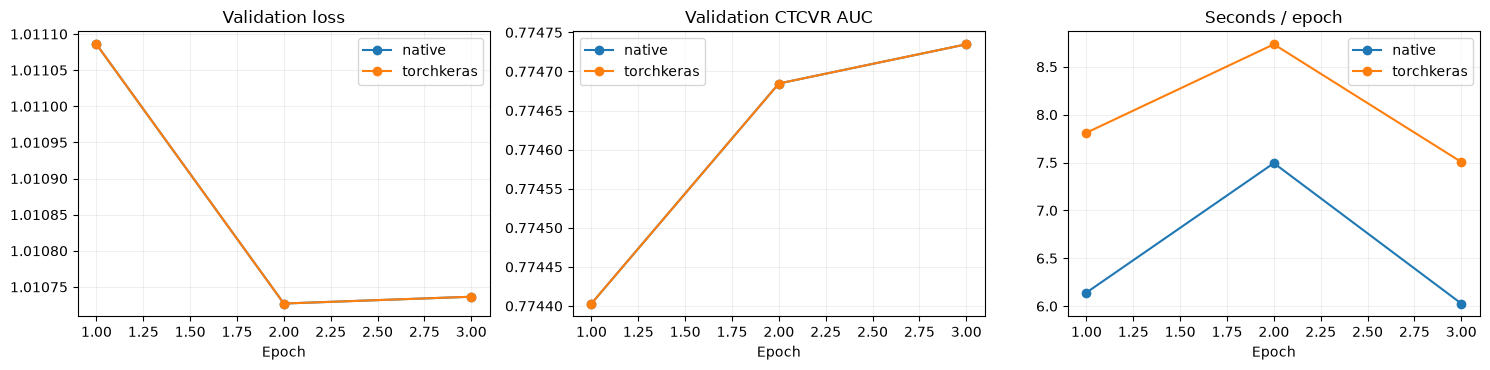

,framework,training_rows,epochs,fit_seconds,samples_per_second,best_epoch
0,native,3000000,3,19.697120,456919.589300,2
1,torchkeras,3000000,3,24.095066,373520.450478,2


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for run in result["runs"]:
    history = pd.DataFrame(run.read_json("history"))
    label = run.metadata["training_framework"]
    axes[0].plot(history.epoch, history.val_loss, marker="o", label=label)
    axes[1].plot(history.epoch, history.val_ctcvr_auc, marker="o", label=label)
    axes[2].plot(history.epoch, history.epoch_seconds, marker="o", label=label)
for ax, title in zip(axes, ["Validation loss", "Validation CTCVR AUC", "Seconds / epoch"]):
    ax.set(title=title, xlabel="Epoch")
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()
display(
    pd.DataFrame(
        [
            {
                "framework": r.metadata["training_framework"],
                "training_rows": r.result["training_rows"],
                "epochs": r.result["epochs_run"],
                "fit_seconds": r.result["training_seconds"],
                "samples_per_second": r.result["samples_per_second"],
                "best_epoch": r.result["best_epoch"],
            }
            for r in result["runs"]
        ]
    )
)

## 9. 保存后恢复：网络 + 预处理

权重加载使用 weights_only=True。预测输入通过保存的训练统计处理；不会再次 fit。
此处从磁盘读取一批原始测试样本，恢复三种概率并验证联合概率约束。

In [12]:
saved = result["runs"][1]
restored = load_pytorch(saved, ESMMMoE(**saved.read_json("model_config"))).eval()
prep = saved.read_json("preprocessor")
left = manifest["boundaries"]["test"][0]
cat, cont = transform_batch(
    np.load(ROOT / f"dataset_{ROWS}" / "categorical.npy", mmap_mode="r")[left : left + 10],
    np.load(ROOT / f"dataset_{ROWS}" / "continuous.npy", mmap_mode="r")[left : left + 10],
    prep,
)
with torch.no_grad():
    prediction = restored(cat, cont)
torch.testing.assert_close(prediction["ctcvr"], prediction["ctr"] * prediction["cvr"])
display(pd.DataFrame({k: v.numpy().ravel() for k, v in prediction.items()}))
for run in result["runs"]:
    run.verify_artifacts()
print("权重、预处理、历史与 TensorBoard 归档校验通过。")

,ctr,cvr,ctcvr
0,0.347971,0.342625,0.119224
1,0.537052,0.059801,0.032116
2,0.690856,0.107384,0.074187
3,0.304551,0.102791,0.031305
4,0.638122,0.431464,0.275326
5,0.684397,0.250513,0.171451
6,0.400448,0.252073,0.100942
7,0.153237,0.245158,0.037567
8,0.291043,0.052460,0.015268
9,0.448297,0.400914,0.179728


权重、预处理、历史与 TensorBoard 归档校验通过。


## 10. TensorBoard、1000 万行与真实数据

```bash
uv run --extra tensorboard tensorboard --logdir experiments/esmm_mmoe_large
uv run --extra torchkeras --extra tensorboard python examples/modeling/esmm_mmoe_large_scale.py \
  --rows 10000000 --epochs 3 --batch-size 4096
```

每次运行产生新 Run；相同生成参数的数据可以复用。数据位于 experiments/esmm_mmoe_large/dataset_5000000。
真实业务应先明确时间窗口、标签成熟度和切分，train-only 拟合统计。
本例的连续切分建立在 IID 合成生成器上，不代表真实业务可以忽略时间漂移。
完整断点续训、多卡、样本权重和缺失标签 mask 不在这一版范围内。

若同一个 macOS 内核要同时运行 LightGBM 和 PyTorch，请阅读文字指南的 OpenMP 兼容说明；
可分别训练后使用无需后端的 Experiment 比较历史。

## Linux CPU / NVIDIA CUDA

本 Notebook 保存的是 Mac CPU 实测结果。两个脚本入口均支持 `--device cpu|cuda`，
Python 函数 `run_guide` / `run_large_guide` 可传 `device="cuda"`。
CUDA 不可用会提前报错；切换设备需重启内核，避免 Accelerate 的全局状态影响。
大数据示例默认 `num_workers=0`，单进程单 GPU、float32。

Linux 安装、CPU/CUDA 分别启动、实际 GPU 验收命令与范围见
[完整指南第 19 节](esmm_mmoe_complete_guide.md#19-linux-cpu-与-nvidia-cuda-部署)。
Ubuntu CI 已配置；尚未在 Linux 或 NVIDIA GPU 上实际验收。
